In [1]:
from langchain_core.tools import tool

@tool
def convert_currency(amount: float, from_currency: str, to_currency: str):
    """currency converter from USD to EUR"""
    print(f"Converting {amount} from {from_currency} to {to_currency}")
    return f"{amount * 1.1:.2f} {to_currency}"  # fixed mock rate


In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI
import dotenv

dotenv.load_dotenv()
model =  ChatGoogleGenerativeAI(model="gemini-2.5-flash").bind_tools([convert_currency])


In [3]:
def call_llm(state):
    return {"messages": [model.invoke(state["messages"])]}


In [4]:
from langgraph.types import Command, interrupt
from typing_extensions import Literal

def human_review_node(state) -> Command[Literal["call_llm", "run_tool"]]:
    last_message = state["messages"][-1]
    tool_call = last_message.tool_calls[-1]

    human_review = interrupt({
        "question": "Is this tool call correct?",
        "tool_call": tool_call,
    })

    review_action = human_review["action"]
    review_data = human_review.get("data")

    if review_action == "continue":
        return Command(goto="run_tool")
    elif review_action == "update":
        updated_message = {
            "role": "ai",
            "content": last_message.content,
            "tool_calls": [
                {
                    "id": tool_call["id"],
                    "name": tool_call["name"],
                    "args": review_data,
                }
            ],
            "id": last_message.id,
        }
        return Command(goto="run_tool", update={"messages": [updated_message]})


In [5]:
from langgraph.graph import END

def route_after_llm(state):
    if len(state["messages"][-1].tool_calls) == 0:
        return END
    return "human_review_node"


In [6]:
from langgraph.graph import StateGraph, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode

tools = ToolNode(tools=[convert_currency])

builder = StateGraph(MessagesState)
builder.add_node("call_llm", call_llm)
builder.add_node("run_tool", tools)
builder.add_node("human_review_node", human_review_node)

builder.add_conditional_edges("call_llm", route_after_llm, {END:END, "human_review_node":"human_review_node"})
builder.add_edge("run_tool", "call_llm")

builder.set_entry_point("call_llm")

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)


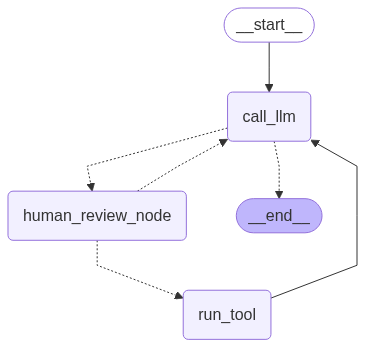

In [7]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
from langchain_core.messages import HumanMessage

initial_input = {"messages": [HumanMessage(content="Convert 100 usd to eur")]}
config = {"configurable": {"thread_id": "123"}}

graph.invoke(initial_input, config=config, stream_mode="updates")


[{'call_llm': {'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'convert_currency', 'arguments': '{"to_currency": "EUR", "amount": 100.0, "from_currency": "USD"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--788b26c9-9092-4a88-b463-ed8d427b0b4f-0', tool_calls=[{'name': 'convert_currency', 'args': {'to_currency': 'EUR', 'amount': 100.0, 'from_currency': 'USD'}, 'id': '162cc801-6a2d-4ad5-bbdc-7644049cf6de', 'type': 'tool_call'}], usage_metadata={'input_tokens': 77, 'output_tokens': 31, 'total_tokens': 186, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 78}})]}},
 {'__interrupt__': (Interrupt(value={'question': 'Is this tool call correct?', 'tool_call': {'name': 'convert_currency', 'args': {'to_currency': 'EUR', 'amount': 100.0, 'from_currency': 'USD'}, 'id': '162cc801-6a2d-4ad5-bbdc-7644049cf6de',

In [9]:
graph.invoke(Command(resume={"action": "continue"}), config=config)


Converting 100.0 from USD to EUR


{'messages': [HumanMessage(content='Convert 100 usd to eur', additional_kwargs={}, response_metadata={}, id='3c27f83a-d188-4ce7-b6bc-61c6f28e0490'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'convert_currency', 'arguments': '{"to_currency": "EUR", "amount": 100.0, "from_currency": "USD"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--788b26c9-9092-4a88-b463-ed8d427b0b4f-0', tool_calls=[{'name': 'convert_currency', 'args': {'to_currency': 'EUR', 'amount': 100.0, 'from_currency': 'USD'}, 'id': '162cc801-6a2d-4ad5-bbdc-7644049cf6de', 'type': 'tool_call'}], usage_metadata={'input_tokens': 77, 'output_tokens': 31, 'total_tokens': 186, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 78}}),
  ToolMessage(content='110.00 EUR', name='convert_currency', id='fb533827-b13c-4216-9026-e927d858cb37', tool_call_id='1

In [12]:
from langchain_core.messages import HumanMessage

initial_input = {"messages": [HumanMessage(content="Convert 100 usd to eur")]}
config = {"configurable": {"thread_id": "123"}}

graph.invoke(initial_input, config=config, stream_mode="updates")


[{'call_llm': {'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'convert_currency', 'arguments': '{"to_currency": "EUR", "amount": 100.0, "from_currency": "USD"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--431d1e42-100f-4ad7-af4c-b90f9b4b2431-0', tool_calls=[{'name': 'convert_currency', 'args': {'to_currency': 'EUR', 'amount': 100.0, 'from_currency': 'USD'}, 'id': '47162faf-3153-4c50-9cd6-34aec3e017fb', 'type': 'tool_call'}], usage_metadata={'input_tokens': 182, 'output_tokens': 31, 'total_tokens': 299, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 86}})]}},
 {'__interrupt__': (Interrupt(value={'question': 'Is this tool call correct?', 'tool_call': {'name': 'convert_currency', 'args': {'to_currency': 'EUR', 'amount': 100.0, 'from_currency': 'USD'}, 'id': '47162faf-3153-4c50-9cd6-34aec3e017fb'

In [13]:
graph.invoke(Command(resume={
    "action": "update",
    "data": {"amount": 100, "from_currency": "$", "to_currency": "EURO"}
}), config=config)


Converting 100.0 from $ to EURO


{'messages': [HumanMessage(content='Convert 100 usd to eur', additional_kwargs={}, response_metadata={}, id='3c27f83a-d188-4ce7-b6bc-61c6f28e0490'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'convert_currency', 'arguments': '{"to_currency": "EUR", "amount": 100.0, "from_currency": "USD"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--788b26c9-9092-4a88-b463-ed8d427b0b4f-0', tool_calls=[{'name': 'convert_currency', 'args': {'to_currency': 'EUR', 'amount': 100.0, 'from_currency': 'USD'}, 'id': '162cc801-6a2d-4ad5-bbdc-7644049cf6de', 'type': 'tool_call'}], usage_metadata={'input_tokens': 77, 'output_tokens': 31, 'total_tokens': 186, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 78}}),
  ToolMessage(content='110.00 EUR', name='convert_currency', id='fb533827-b13c-4216-9026-e927d858cb37', tool_call_id='1

In [21]:
graph.invoke(Command(resume={
    "action": "update",
    "data": {"amount": 20, "from_currency": "USD", "to_currency": "EUR"}
}), config=config)

Converting 20.0 from USD to EUR


{'messages': [HumanMessage(content='Convert 100 usd to eur', additional_kwargs={}, response_metadata={}, id='2c7e713e-af8e-465c-a11a-fdf0395e7d6b'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'convert_currency', 'arguments': '{"to_currency": "EUR", "amount": 100.0, "from_currency": "USD"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--1bee3015-ffa1-48f2-977f-38405123def4-0', tool_calls=[{'name': 'convert_currency', 'args': {'to_currency': 'EUR', 'amount': 100.0, 'from_currency': 'USD'}, 'id': 'a6903c24-cc94-49b4-9f9a-6d1d68e1ef96', 'type': 'tool_call'}], usage_metadata={'input_tokens': 73, 'output_tokens': 31, 'total_tokens': 166, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 62}}),
  ToolMessage(content='110.00 EUR', name='convert_currency', id='2ce1fcce-0ce5-4760-ad1a-2abb748b0320', tool_call_id='a